## PM2.5 Prediction Modeling Using NO2

This notebook develops predictive models for PM2.5 using historical PM2.5 and NO2 data.

### Objectives
- Prepare a merged PM2.5 + NO2 modeling dataset
- Create lag-based features for short-term prediction
- Build a naive baseline model
- Build regression-based and tree-based models
- Compare models with and without NO2
- Evaluate model performance using RMSE, MAE, and R²

## Load libraries and data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [2]:
pm25 = pd.read_csv("../../data/validated/PM25_cityday.csv")
no2 = pd.read_csv("../../data/validated/NO2_cityday.csv")

pm25["Date"] = pd.to_datetime(pm25["Date"])
no2["Date"] = pd.to_datetime(no2["Date"])

print("PM2.5 shape:", pm25.shape)
print("NO2 shape:", no2.shape)

print("\nPM2.5 columns:", pm25.columns.tolist())
print("\nNO2 columns:", no2.columns.tolist())

PM2.5 shape: (256216, 5)
NO2 shape: (218411, 5)

PM2.5 columns: ['City', 'Date', 'PM25_daily', 'Year', 'Month']

NO2 columns: ['City', 'Date', 'NO2_daily', 'Year', 'Month']


In [3]:
pm25 = pm25[["City", "Date", "PM25_daily"]].copy()
no2 = no2[["City", "Date", "NO2_daily"]].copy()

pm25 = pm25.drop_duplicates(subset=["City", "Date"]).sort_values(["City", "Date"])
no2 = no2.drop_duplicates(subset=["City", "Date"]).sort_values(["City", "Date"])

print("PM2.5 duplicate rows after cleaning:", pm25.duplicated(["City", "Date"]).sum())
print("NO2 duplicate rows after cleaning:", no2.duplicated(["City", "Date"]).sum())

PM2.5 duplicate rows after cleaning: 0
NO2 duplicate rows after cleaning: 0


In [4]:
def enforce_daily_frequency(df, value_col):
    all_cities = []

    for city, g in df.groupby("City"):
        g = g.sort_values("Date").set_index("Date")
        full_range = pd.date_range(g.index.min(), g.index.max(), freq="D")
        g = g.reindex(full_range)
        g.index.name = "Date"
        g["City"] = city
        all_cities.append(g.reset_index())

    out = pd.concat(all_cities, ignore_index=True)
    return out[["City", "Date", value_col]]

pm25_daily = enforce_daily_frequency(pm25, "PM25_daily")
no2_daily = enforce_daily_frequency(no2, "NO2_daily")

print("PM2.5 daily shape:", pm25_daily.shape)
print("NO2 daily shape:", no2_daily.shape)

print("\nPM2.5 date range:", pm25_daily["Date"].min(), "to", pm25_daily["Date"].max())
print("NO2 date range:", no2_daily["Date"].min(), "to", no2_daily["Date"].max())

PM2.5 daily shape: (262528, 3)
NO2 daily shape: (221757, 3)

PM2.5 date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00
NO2 date range: 2020-01-01 00:00:00 to 2023-12-31 00:00:00


This is a strong preprocessing step because time-series models require consistent daily spacing. The increase in row counts shows that missing calendar dates were inserted, making the data more suitable for lag-based modeling and fair train-test splitting.

## Merge datasets

In [5]:
model_df = pd.merge(
    pm25_daily,
    no2_daily,
    on=["City", "Date"],
    how="left"
)

print("Merged shape:", model_df.shape)
print(model_df.isna().sum())

Merged shape: (262528, 4)
City              0
Date              0
PM25_daily     6312
NO2_daily     56401
dtype: int64


The merge was completed correctly, but NO₂ has substantial missingness compared with PM2.5. This means NO₂ coverage is weaker across cities and dates, which may limit its predictive power unless missing values are handled carefully.

## Seasonal features

In [6]:
model_df["Year"] = model_df["Date"].dt.year
model_df["Month"] = model_df["Date"].dt.month

def get_season(month):
    if month in [12, 1, 2]:
        return "Winter"
    elif month in [3, 4, 5]:
        return "Spring"
    elif month in [6, 7, 8]:
        return "Summer"
    else:
        return "Fall"

model_df["Season"] = model_df["Month"].apply(get_season)

model_df.head()

,City,Date,PM25_daily,NO2_daily,Year,Month,Season
0,Agassiz,2020-01-01,0.666667,1.500000,2020,1,Winter
1,Agassiz,2020-01-02,1.291667,4.833333,2020,1,Winter
2,Agassiz,2020-01-03,1.333333,8.750000,2020,1,Winter
3,Agassiz,2020-01-04,3.791667,5.250000,2020,1,Winter
4,Agassiz,2020-01-05,4.291667,9.416667,2020,1,Winter


Seasonal variables were added successfully, which is useful because air pollution commonly varies by season. Missing NO₂ values were intentionally retained at this stage and later handled through the preprocessing pipeline using training-data-based imputation. This avoids leakage from future observations and keeps the modeling workflow methodologically sound.

## Create lag features

In [8]:
lag_cols = {
    "PM25_daily": [1, 3, 7],
    "NO2_daily": [1, 3, 7]
}

for col, lags in lag_cols.items():
    for lag in lags:
        model_df[f"{col.split('_')[0]}_lag{lag}"] = model_df.groupby("City")[col].shift(lag)

model_df.head()

,City,Date,PM25_daily,NO2_daily,Year,Month,Season,PM25_lag1,PM25_lag3,PM25_lag7,NO2_lag1,NO2_lag3,NO2_lag7
0,Agassiz,2020-01-01,0.666667,1.500000,2020,1,Winter,NaN,NaN,NaN,NaN,NaN,NaN
1,Agassiz,2020-01-02,1.291667,4.833333,2020,1,Winter,0.666667,NaN,NaN,1.500000,NaN,NaN
2,Agassiz,2020-01-03,1.333333,8.750000,2020,1,Winter,1.291667,NaN,NaN,4.833333,NaN,NaN
3,Agassiz,2020-01-04,3.791667,5.250000,2020,1,Winter,1.333333,0.666667,NaN,8.750000,1.500000,NaN
4,Agassiz,2020-01-05,4.291667,9.416667,2020,1,Winter,3.791667,1.291667,NaN,5.250000,4.833333,NaN


Lag features for PM2.5 and NO₂ (1-day, 3-day, and 7-day) were created to capture short-term temporal patterns in air pollution levels. These features allow the models to use recent pollution history when predicting future PM2.5 concentrations.

## Final modeling dataset

In [9]:
required_cols = [
    "City", "Date",
    "PM25_daily", "NO2_daily",
    "Year", "Month", "Season",
    "PM25_lag1", "PM25_lag3", "PM25_lag7",
    "NO2_lag1", "NO2_lag3", "NO2_lag7"
]
model_df = model_df[required_cols].copy()
model_df = model_df.dropna(subset=["PM25_daily", "PM25_lag1", "PM25_lag3", "PM25_lag7"])

print("Final modeling shape:", model_df.shape)
print(model_df.isna().sum())

Final modeling shape: (251878, 13)
City              0
Date              0
PM25_daily        0
NO2_daily     48106
Year              0
Month             0
Season            0
PM25_lag1         0
PM25_lag3         0
PM25_lag7         0
NO2_lag1      48106
NO2_lag3      48106
NO2_lag7      48106
dtype: int64


## Train/test split

In [10]:
train = model_df[model_df["Date"] < "2023-01-01"].copy()
test = model_df[model_df["Date"] >= "2023-01-01"].copy()

print("Train shape:", train.shape)
print("Test shape:", test.shape)

print("\nTrain date range:", train["Date"].min(), "to", train["Date"].max())
print("Test date range:", test["Date"].min(), "to", test["Date"].max())

Train shape: (189705, 13)
Test shape: (62173, 13)

Train date range: 2020-01-08 00:00:00 to 2022-12-31 00:00:00
Test date range: 2023-01-01 00:00:00 to 2023-12-31 00:00:00


The dataset was split chronologically into training and testing sets, with 2020–2022 used for training and 2023 used for testing. This approach ensures that the models are evaluated on future observations, which better reflects real forecasting conditions.

## Define feature sets

In [11]:
features_pm25_only_num = [
    "PM25_lag1", "PM25_lag3", "PM25_lag7",
    ]

features_with_no2_num = [
    "PM25_lag1", "PM25_lag3", "PM25_lag7",
    "NO2_daily", "NO2_lag1", "NO2_lag3", "NO2_lag7",
]

categorical_features = ["City", "Season"]

target = "PM25_daily"

X_train_pm25 = train[features_pm25_only_num + categorical_features]
X_test_pm25 = test[features_pm25_only_num + categorical_features]

X_train_no2 = train[features_with_no2_num + categorical_features]
X_test_no2 = test[features_with_no2_num + categorical_features]

y_train = train[target]
y_test = test[target]

## Baseline model

In [12]:
baseline_pred = test["PM25_lag1"]

baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
baseline_r2 = r2_score(y_test, baseline_pred)

print("Naive Baseline Results")
print("RMSE:", round(baseline_rmse, 3))
print("MAE :", round(baseline_mae, 3))
print("R²  :", round(baseline_r2, 3))

Naive Baseline Results
RMSE: 15.595
MAE : 4.959
R²  : 0.32


The naive baseline model, which predicts PM2.5 using the previous day’s value, provided moderate performance. This indicates that PM2.5 exhibits strong temporal persistence, where recent pollution levels influence current conditions.

## Preprocessing helper

In [13]:
def build_preprocessor(numeric_features, categorical_features):
    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore"))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_features),
            ("cat", categorical_transformer, categorical_features)
        ]
    )
    return preprocessor

## Linear Regression: PM2.5 only

In [14]:
preprocessor_pm25 = build_preprocessor(features_pm25_only_num, categorical_features)

lr_pm25 = Pipeline(steps=[
    ("preprocessor", preprocessor_pm25),
    ("model", LinearRegression())
])

lr_pm25.fit(X_train_pm25, y_train)
pred_lr_pm25 = lr_pm25.predict(X_test_pm25)

lr_pm25_rmse = np.sqrt(mean_squared_error(y_test, pred_lr_pm25))
lr_pm25_mae = mean_absolute_error(y_test, pred_lr_pm25)
lr_pm25_r2 = r2_score(y_test, pred_lr_pm25)

print("Linear Regression (PM2.5 only)")
print("RMSE:", round(lr_pm25_rmse, 3))
print("MAE :", round(lr_pm25_mae, 3))
print("R²  :", round(lr_pm25_r2, 3))

Linear Regression (PM2.5 only)
RMSE: 14.285
MAE : 4.492
R²  : 0.43


The linear regression model using PM2.5 lag variables improves prediction accuracy compared with the naive baseline. This indicates that incorporating multiple past observations helps capture short-term temporal patterns in PM2.5 levels. The results suggest that PM2.5 history provides meaningful predictive information.

## Linear Regression: PM2.5 + NO2

In [15]:
preprocessor_no2 = build_preprocessor(features_with_no2_num, categorical_features)

lr_no2 = Pipeline(steps=[
    ("preprocessor", preprocessor_no2),
    ("model", LinearRegression())
])

lr_no2.fit(X_train_no2, y_train)
pred_lr_no2 = lr_no2.predict(X_test_no2)

lr_no2_rmse = np.sqrt(mean_squared_error(y_test, pred_lr_no2))
lr_no2_mae = mean_absolute_error(y_test, pred_lr_no2)
lr_no2_r2 = r2_score(y_test, pred_lr_no2)

print("Linear Regression (+NO2)")
print("RMSE:", round(lr_no2_rmse, 3))
print("MAE :", round(lr_no2_mae, 3))
print("R²  :", round(lr_no2_r2, 3))

Linear Regression (+NO2)
RMSE: 14.156
MAE : 4.319
R²  : 0.44


Adding NO₂ features slightly improves model performance. This suggests that NO₂ contains additional environmental information that contributes to predicting PM2.5 levels. However, the improvement remains modest within a linear modeling framework.

## Random Forest: PM2.5 only

In [16]:
rf_pm25 = Pipeline(steps=[
    ("preprocessor", preprocessor_pm25),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_pm25.fit(X_train_pm25, y_train)
pred_rf_pm25 = rf_pm25.predict(X_test_pm25)

rf_pm25_rmse = np.sqrt(mean_squared_error(y_test, pred_rf_pm25))
rf_pm25_mae = mean_absolute_error(y_test, pred_rf_pm25)
rf_pm25_r2 = r2_score(y_test, pred_rf_pm25)

print("Random Forest (PM2.5 only)")
print("RMSE:", round(rf_pm25_rmse, 3))
print("MAE :", round(rf_pm25_mae, 3))
print("R²  :", round(rf_pm25_r2, 3))

Random Forest (PM2.5 only)
RMSE: 14.476
MAE : 4.559
R²  : 0.414


The Random Forest model captures nonlinear relationships between lagged PM2.5 variables. Its performance is comparable to the linear model, indicating that PM2.5 historical values remain the primary driver of predictions. Without additional predictors, the improvement from nonlinear modeling is limited.

## Random Forest: PM2.5 + NO2

In [17]:
rf_no2 = Pipeline(steps=[
    ("preprocessor", preprocessor_no2),
    ("model", RandomForestRegressor(
        n_estimators=300,
        max_depth=12,
        min_samples_leaf=3,
        random_state=42,
        n_jobs=-1
    ))
])

rf_no2.fit(X_train_no2, y_train)
pred_rf_no2 = rf_no2.predict(X_test_no2)

rf_no2_rmse = np.sqrt(mean_squared_error(y_test, pred_rf_no2))
rf_no2_mae = mean_absolute_error(y_test, pred_rf_no2)
rf_no2_r2 = r2_score(y_test, pred_rf_no2)

print("Random Forest (+NO2)")
print("RMSE:", round(rf_no2_rmse, 3))
print("MAE :", round(rf_no2_mae, 3))
print("R²  :", round(rf_no2_r2, 3))

Random Forest (+NO2)
RMSE: 13.881
MAE : 4.271
R²  : 0.462


The Random Forest model including both PM2.5 and NO₂ features produces the best predictive performance. This suggests that combining pollutant interactions with nonlinear modeling improves the ability to capture complex pollution dynamics. The results highlight the value of incorporating related pollutants in air quality forecasting.

## Model comparison table 

In [18]:
comparison = pd.DataFrame({
    "Model": [
        "Naive Baseline",
        "Linear Regression (PM2.5 only)",
        "Linear Regression (+NO2)",
        "Random Forest (PM2.5 only)",
        "Random Forest (+NO2)"
    ],
    "RMSE": [
        baseline_rmse,
        lr_pm25_rmse,
        lr_no2_rmse,
        rf_pm25_rmse,
        rf_no2_rmse
    ],
    "MAE": [
        baseline_mae,
        lr_pm25_mae,
        lr_no2_mae,
        rf_pm25_mae,
        rf_no2_mae
    ],
    "R2": [
        baseline_r2,
        lr_pm25_r2,
        lr_no2_r2,
        rf_pm25_r2,
        rf_no2_r2
    ]
}).sort_values("RMSE").reset_index(drop=True)

comparison

,Model,RMSE,MAE,R2
0,Random Forest (+NO2),13.881125,4.270914,0.461518
1,Linear Regression (+NO2),14.155592,4.319433,0.440013
2,Linear Regression (PM2.5 only),14.285056,4.492278,0.429723
3,Random Forest (PM2.5 only),14.475770,4.558932,0.414394
4,Naive Baseline,15.594626,4.958778,0.320371


Overall, models that include both PM2.5 history and NO₂ variables perform better than those relying on PM2.5 alone. The Random Forest model achieves the best overall performance, indicating that nonlinear methods are effective for capturing complex environmental relationships. These results demonstrate that combining pollutant data improves PM2.5 prediction accuracy.

## Predicted vs actual scatter plot

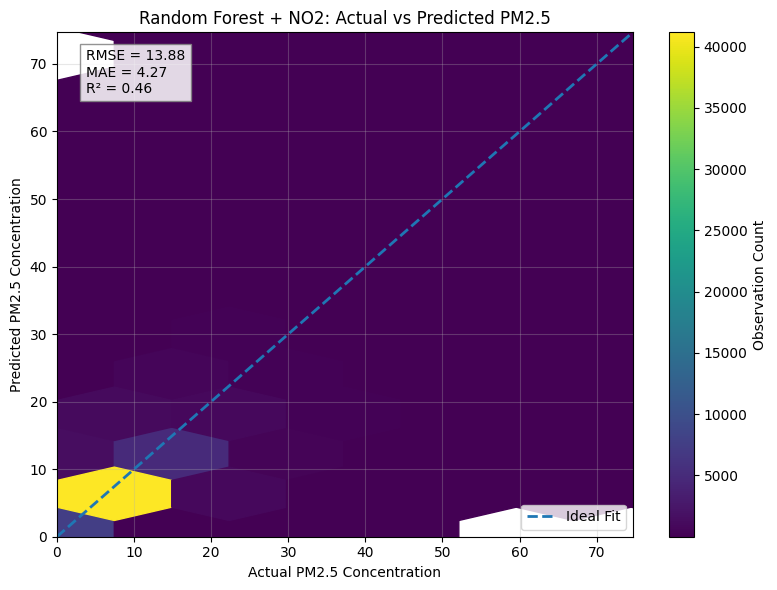

In [19]:
rmse = np.sqrt(mean_squared_error(y_test, pred_rf_no2))
mae = mean_absolute_error(y_test, pred_rf_no2)
r2 = r2_score(y_test, pred_rf_no2)

upper_limit = np.percentile(np.concatenate([y_test, pred_rf_no2]), 99)

plt.figure(figsize=(8, 6))

hb = plt.hexbin(
    y_test,
    pred_rf_no2,
    gridsize=40,
    mincnt=1
)

plt.colorbar(hb, label="Observation Count")

plt.plot(
    [0, upper_limit],
    [0, upper_limit],
    linestyle="--",
    linewidth=2,
    label="Ideal Fit"
)

plt.xlim(0, upper_limit)
plt.ylim(0, upper_limit)

plt.xlabel("Actual PM2.5 Concentration")
plt.ylabel("Predicted PM2.5 Concentration")
plt.title("Random Forest + NO2: Actual vs Predicted PM2.5")
plt.grid(True, alpha=0.3)

plt.text(
    0.05 * upper_limit,
    0.88 * upper_limit,
    f"RMSE = {rmse:.2f}\nMAE = {mae:.2f}\nR² = {r2:.2f}",
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="gray")
)

plt.legend()
plt.tight_layout()
plt.show()

## Correct over-time plot for one city only

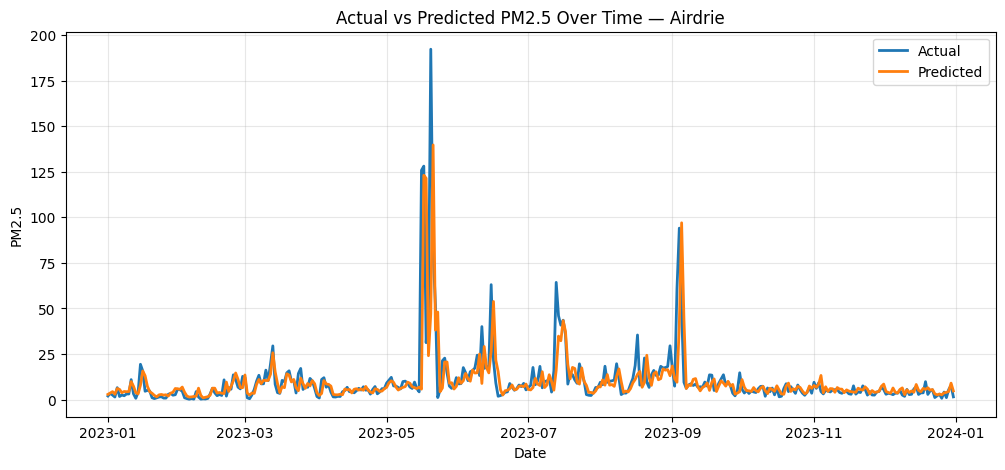

In [20]:
best_city = (
    test.groupby("City")["PM25_daily"]
    .count()
    .sort_values(ascending=False)
    .index[0]
)

city_plot = test[test["City"] == best_city][["City", "Date", "PM25_daily", "Season"]].copy()
city_plot["Predicted_PM25"] = pred_rf_no2[test["City"] == best_city]

plt.figure(figsize=(12, 5))
plt.plot(city_plot["Date"], city_plot["PM25_daily"], label="Actual", linewidth=2)
plt.plot(city_plot["Date"], city_plot["Predicted_PM25"], label="Predicted", linewidth=2)
plt.title(f"Actual vs Predicted PM2.5 Over Time — {best_city}")
plt.xlabel("Date")
plt.ylabel("PM2.5")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Evaluate by city

In [21]:
test_results = test[["City", "Date", "Season", "PM25_daily"]].copy()
test_results["Pred_RF_NO2"] = pred_rf_no2
test_results["Pred_LR_NO2"] = pred_lr_no2
test_results["Pred_Baseline"] = baseline_pred.values

def metric_table(group, pred_col):
    rmse = np.sqrt(mean_squared_error(group["PM25_daily"], group[pred_col]))
    mae = mean_absolute_error(group["PM25_daily"], group[pred_col])
    r2 = r2_score(group["PM25_daily"], group[pred_col])
    return pd.Series({"RMSE": rmse, "MAE": mae, "R2": r2})

city_eval_rf = (
    test_results.groupby("City")
    .apply(lambda g: metric_table(g, "Pred_RF_NO2"))
    .reset_index()
    .sort_values("RMSE")
)

city_eval_rf

C:\Users\Jaya\AppData\Local\Temp\ipykernel_37024\2079611757.py:14: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metric_table(g, "Pred_RF_NO2"))


,City,RMSE,MAE,R2
123,Powell River,1.651390,1.226211,0.345100
147,Southampton,1.830885,1.304811,0.276715
27,Corner Brook,1.917123,1.309284,0.294002
23,Charlottetown,1.939215,1.335606,0.275203
173,Wellington,2.136938,1.390741,0.290596
...,...,...,...,...
47,Fort Mckay,33.662698,13.981733,0.334339
111,Norman Wells,35.928284,9.214899,0.412654
179,Yellowknife,39.167848,15.695539,0.452472
141,Senneterre,40.204785,7.247575,0.352903


## Evaluate by season

In [22]:
season_eval_rf = (
    test_results.groupby("Season")
    .apply(lambda g: metric_table(g, "Pred_RF_NO2"))
    .reset_index()
    .sort_values("RMSE")
)

season_eval_rf

C:\Users\Jaya\AppData\Local\Temp\ipykernel_37024\3614301711.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: metric_table(g, "Pred_RF_NO2"))


,Season,RMSE,MAE,R2
3,Winter,3.410223,2.230811,0.516627
0,Fall,11.853610,3.647509,0.498967
1,Spring,14.680801,3.579210,0.492225
2,Summer,19.954235,7.556336,0.387208


## Improvement from adding NO2

In [23]:
improvement_table = pd.DataFrame({
    "Model Family": ["Linear Regression", "Random Forest"],
    "RMSE without NO2": [lr_pm25_rmse, rf_pm25_rmse],
    "RMSE with NO2": [lr_no2_rmse, rf_no2_rmse],
    "RMSE Improvement": [
        lr_pm25_rmse - lr_no2_rmse,
        rf_pm25_rmse - rf_no2_rmse
    ],
    "MAE without NO2": [lr_pm25_mae, rf_pm25_mae],
    "MAE with NO2": [lr_no2_mae, rf_no2_mae],
    "MAE Improvement": [
        lr_pm25_mae - lr_no2_mae,
        rf_pm25_mae - rf_no2_mae
    ]
})

improvement_table

,Model Family,RMSE without NO2,RMSE with NO2,RMSE Improvement,MAE without NO2,MAE with NO2,MAE Improvement
0,Linear Regression,14.285056,14.155592,0.129463,4.492278,4.319433,0.172845
1,Random Forest,14.475770,13.881125,0.594645,4.558932,4.270914,0.288018


## Feature importance for Random Forest + NO2

In [24]:
rf_model = rf_no2.named_steps["model"]
preprocessor = rf_no2.named_steps["preprocessor"]

feature_names = preprocessor.get_feature_names_out()
importances = rf_model.feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
0,num__PM25_lag1,0.747939
3,num__NO2_daily,0.071716
1,num__PM25_lag3,0.036192
4,num__NO2_lag1,0.034290
2,num__PM25_lag7,0.028858
6,num__NO2_lag7,0.026155
5,num__NO2_lag3,0.016120
29,cat__City_Castlegar,0.007190
193,cat__Season_Summer,0.006191
191,cat__Season_Fall,0.004702


## Feature importance plot

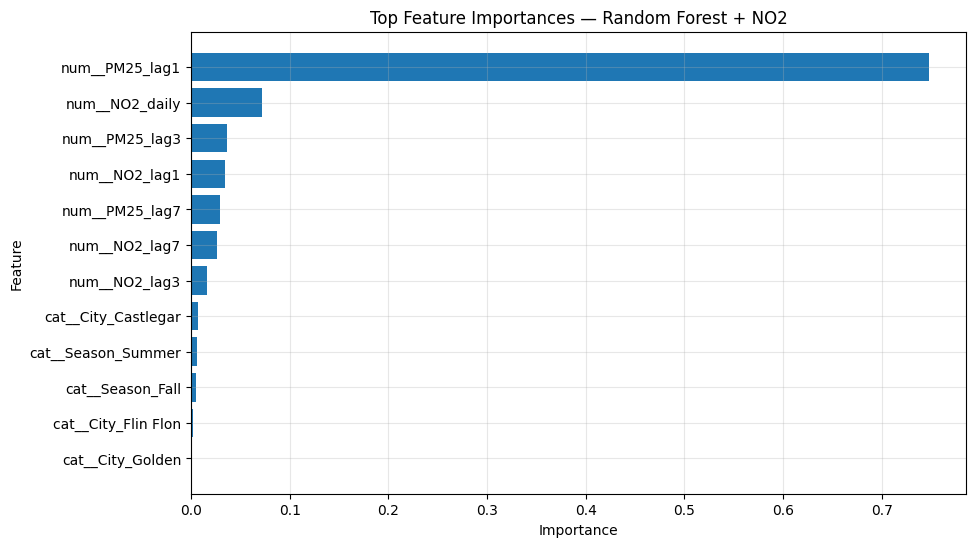

In [25]:
top_features = feature_importance.head(12).sort_values("Importance")

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Feature Importances — Random Forest + NO2")
plt.grid(True, alpha=0.3)
plt.show()

Feature importance analysis shows that previous-day PM2.5 is the strongest predictor of current PM2.5 levels. Several NO₂ variables also appear among the important features, confirming that NO₂ contributes additional predictive signal. This supports the idea that pollutant interactions influence urban air quality patterns.

## Residual diagnostics

In [29]:
test_results = test[["City", "Date", "PM25_daily", "Season"]].copy()
test_results["Pred_RF_NO2"] = pred_rf_no2
test_results["Residual"] = test_results["PM25_daily"] - test_results["Pred_RF_NO2"]

print(test_results.columns.tolist())
test_results.head()

['City', 'Date', 'PM25_daily', 'Season', 'Pred_RF_NO2', 'Residual']


,City,Date,PM25_daily,Season,Pred_RF_NO2,Residual
1105,Agassiz,2023-01-10,1.833333,Winter,3.140660,-1.307327
1106,Agassiz,2023-01-11,2.250000,Winter,2.744836,-0.494836
1107,Agassiz,2023-01-12,1.375000,Winter,3.475028,-2.100028
1108,Agassiz,2023-01-13,2.791667,Winter,3.012863,-0.221197
1109,Agassiz,2023-01-14,1.541667,Winter,3.250691,-1.709024


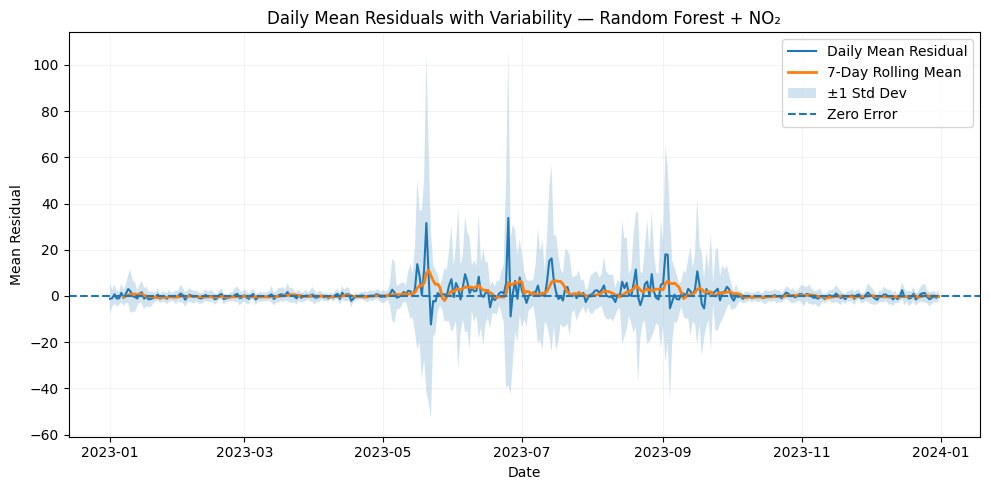

In [32]:
daily_resid = (
    test_results.groupby("Date")
    .agg(
        mean_residual=("Residual", "mean"),
        std_residual=("Residual", "std")
    )
    .reset_index()
)

daily_resid["rolling_mean"] = daily_resid["mean_residual"].rolling(7).mean()

plt.figure(figsize=(10,5))

plt.plot(
    daily_resid["Date"],
    daily_resid["mean_residual"],
    label="Daily Mean Residual",
    linewidth=1.5
)

plt.plot(
    daily_resid["Date"],
    daily_resid["rolling_mean"],
    linewidth=2,
    label="7-Day Rolling Mean"
)

plt.fill_between(
    daily_resid["Date"],
    daily_resid["mean_residual"] - daily_resid["std_residual"],
    daily_resid["mean_residual"] + daily_resid["std_residual"],
    alpha=0.2,
    label="±1 Std Dev"
)

plt.axhline(0, linestyle="--", linewidth=1.5, label="Zero Error")

plt.title("Daily Mean Residuals with Variability — Random Forest + NO₂")
plt.xlabel("Date")
plt.ylabel("Mean Residual")

plt.legend()
plt.grid(True, alpha=0.15)

plt.tight_layout()
plt.show()

The residual plot shows that most prediction errors fluctuate around zero, indicating that the Random Forest model with NO₂ does not exhibit strong systematic bias. However, the variability increases noticeably during the mid-year period (May–September), suggesting that the model struggles more during periods of higher pollution volatility. The 7-day rolling mean remains close to zero overall, which indicates that the model predictions are generally stable, although occasional spikes highlight short-term prediction errors during extreme pollution events.

In [ ]:
best_model = comparison.sort_values("RMSE").iloc[0]

print("Best model based on RMSE:")
print(best_model)

Best model based on RMSE:
Model    Random Forest (+NO2)
RMSE                13.881125
MAE                  4.270914
R2                   0.461518
Name: 0, dtype: object


The model comparison results show that Random Forest with NO₂ features achieved the best performance, with the lowest RMSE (13.88) and MAE (4.27) and the highest R² (0.46). This indicates that incorporating NO₂ alongside historical PM2.5 values improves predictive accuracy and helps capture more variation in PM2.5 levels. Overall, the results suggest that nonlinear models with multiple pollutant indicators provide more reliable PM2.5 predictions than simpler approaches.